# Inventory Optimization EDA


**Core questions**
- How does total demand behave over time?
- Which categories and SKUs drive the most demand?
- How do promotions, festivals, and other demand drivers affect units sold?
- What inventory and supplier signals matter for future optimization?

In [ ]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # type: ignore
from IPython.display import Markdown, display
from scipy.stats import f_oneway, ttest_ind

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

In [2]:
project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
elif (project_root / 'inventory_optimization').exists():
    project_root = project_root / 'inventory_optimization'

processed_dir = project_root / 'data' / 'processed'

# Load the cleaned datasets created earlier in the pipeline.
sales = pd.read_csv(processed_dir / 'sales_clean.csv')
products = pd.read_csv(processed_dir / 'products_clean.csv')
inventory = pd.read_csv(processed_dir / 'inventory_clean.csv')
suppliers = pd.read_csv(processed_dir / 'suppliers_clean.csv')

## 1. Data Preparation

We load the processed datasets, parse date fields, and create a merged table for category, inventory, and supplier analysis.

In [3]:
# Convert the sales date column into datetime for time-based analysis.
sales['date'] = pd.to_datetime(sales['date'])

# Avoid duplicate supplier_id columns during joins.
inventory_features = inventory.drop(columns=['supplier_id'], errors='ignore').copy()

# Merge product, supplier, and inventory context into the sales table.
sales_enriched = sales.merge(products, on='sku_id', how='left')
sales_enriched = sales_enriched.merge(inventory_features, on='sku_id', how='left')
sales_enriched = sales_enriched.merge(suppliers, on='supplier_id', how='left')
sales_enriched = sales_enriched.sort_values(['sku_id', 'date']).reset_index(drop=True)

print('Sales shape:', sales.shape)
print('Products shape:', products.shape)
print('Inventory shape:', inventory.shape)
print('Suppliers shape:', suppliers.shape)
print('Merged shape:', sales_enriched.shape)
print('Date range:', sales['date'].min().date(), 'to', sales['date'].max().date())

Sales shape: (14640, 32)
Products shape: (40, 7)
Inventory shape: (40, 7)
Suppliers shape: (10, 4)
Merged shape: (14640, 46)
Date range: 2024-01-01 to 2024-12-31


## 2. Dataset Overview

This section checks the overall size, schema, and a few core summary statistics before we analyze behavior.

In [4]:
overview = pd.DataFrame({
    'metric': [
        'sales_rows',
        'unique_skus',
        'unique_categories',
        'unique_suppliers',
        'avg_units_sold',
        'median_units_sold',
        'std_units_sold'
    ],
    'value': [
        len(sales),
        sales['sku_id'].nunique(),
        products['category'].nunique(),
        suppliers['supplier_id'].nunique(),
        sales['units_sold'].mean(),
        sales['units_sold'].median(),
        sales['units_sold'].std()
    ]
})

display(overview)
display(sales[['units_sold', 'selling_price', 'discount_pct', 'gross_revenue']].describe().T)

buffer = StringIO()
sales.info(buf=buffer)
print(buffer.getvalue())

,metric,value
0,sales_rows,"14,640.00"
1,unique_skus,40.00
2,unique_categories,6.00
3,unique_suppliers,10.00
4,avg_units_sold,29.53
5,median_units_sold,28.00
6,std_units_sold,7.67


,count,mean,std,min,25%,50%,75%,max
units_sold,"14,640.00",29.53,7.67,10.00,24.00,28.00,34.00,60.00
selling_price,"14,640.00",857.72,493.54,111.52,488.87,756.32,"1,123.63","2,374.29"
discount_pct,"14,640.00",0.11,0.13,0.00,0.03,0.07,0.10,0.50
gross_revenue,"14,640.00","24,805.09","14,402.34","2,653.40","13,311.71","22,808.85","32,783.27","92,942.40"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14640 non-null  datetime64[ns]
 1   sku_id                    14640 non-null  object        
 2   units_sold                14640 non-null  int64         
 3   selling_price             14640 non-null  float64       
 4   gross_revenue             14640 non-null  float64       
 5   promo_flag                14640 non-null  int64         
 6   discount_pct              14640 non-null  float64       
 7   month                     14640 non-null  int64         
 8   week_of_year              14640 non-null  int64         
 9   day_of_week               14640 non-null  int64         
 10  is_weekend                14640 non-null  int64         
 11  is_festival_month         14640 non-null  int64         
 12  is_payday_period  

## 3. Demand Trend Analysis

We begin with total demand over time to spot peaks, seasonality, and possible planning pressure points.

,month,units_sold
11,12,41138
10,11,40332
9,10,40171
4,5,35847
7,8,35468
0,1,35224
2,3,35165
6,7,34527
5,6,34151
8,9,33972


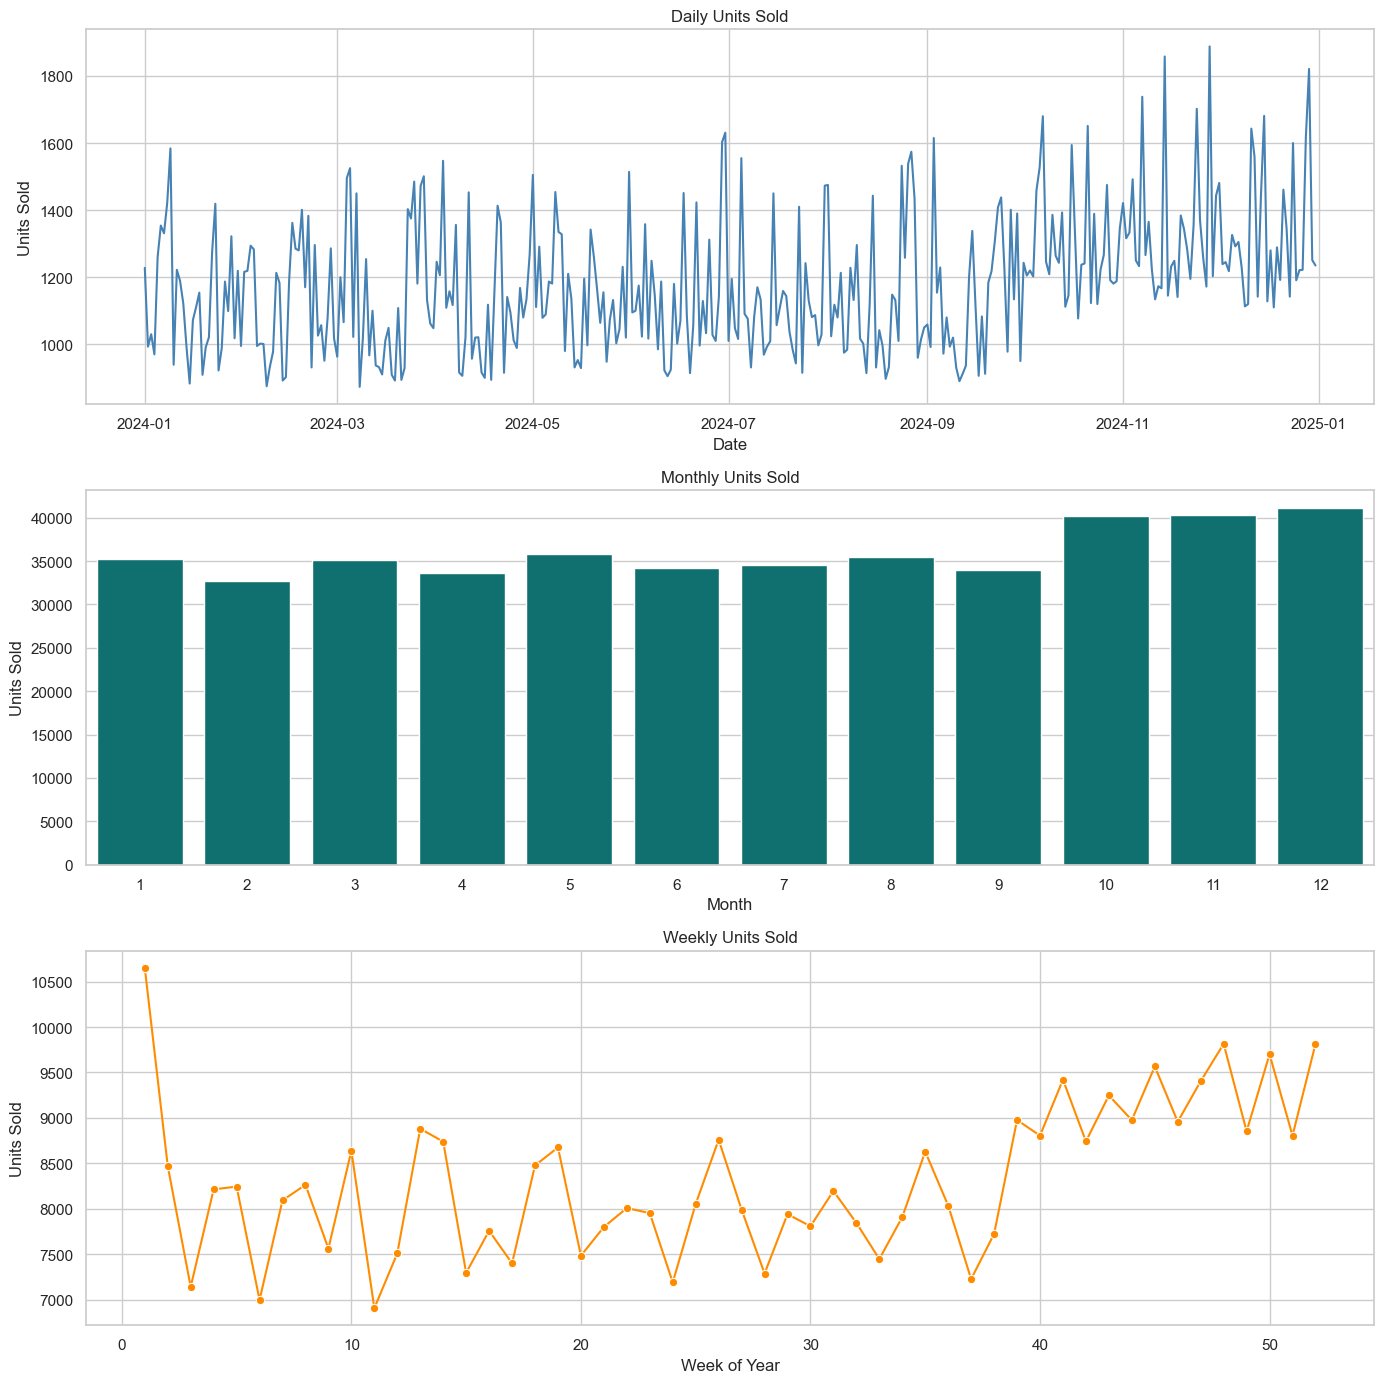

In [ ]:
daily_demand = sales.groupby('date', as_index=False)['units_sold'].sum() # This line calculates the sum of units sold according to date 
monthly_demand = sales.groupby('month', as_index=False)['units_sold'].sum() # This line calculates the demand of units monthly
weekly_demand = sales.groupby('week_of_year', as_index=False)['units_sold'].sum() # This line calculates the demand of units weekly

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

sns.lineplot(data=daily_demand, x='date', y='units_sold', ax=axes[0], color='steelblue')    # type: ignore
axes[0].set_title('Daily Units Sold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Units Sold')

sns.barplot(data=monthly_demand, x='month', y='units_sold', ax=axes[1], color='teal')    # type: ignore
axes[1].set_title('Monthly Units Sold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Units Sold')

sns.lineplot(data=weekly_demand, x='week_of_year', y='units_sold', marker='o', ax=axes[2], color='darkorange') # type: ignore
axes[2].set_title('Weekly Units Sold')
axes[2].set_xlabel('Week of Year')
axes[2].set_ylabel('Units Sold')

plt.tight_layout()

display(monthly_demand.sort_values('units_sold', ascending=False).head(12)) # type: ignore

## 4. Category Analysis

Here we identify which categories contribute the most units sold and how demand is distributed across the assortment.

,category,total_units,average_units,demand_std,demand_share_pct
0,Electronics Accessories,134038,33.29,7.25,31.01
1,Home & Kitchen,89931,30.71,7.58,20.80
2,Fitness & Wellness,66021,25.77,6.31,15.27
3,Beauty & Personal Care,64653,29.44,6.97,14.96
4,Home Cleaning,57404,26.14,7.06,13.28
5,Stationery & Office,20242,27.65,7.24,4.68


/var/folders/qm/8t8rxfy10f7b3mdcgk6yhkgh0000gp/T/ipykernel_4614/158741699.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_summary, x='category', y='total_units', palette='Blues_d')


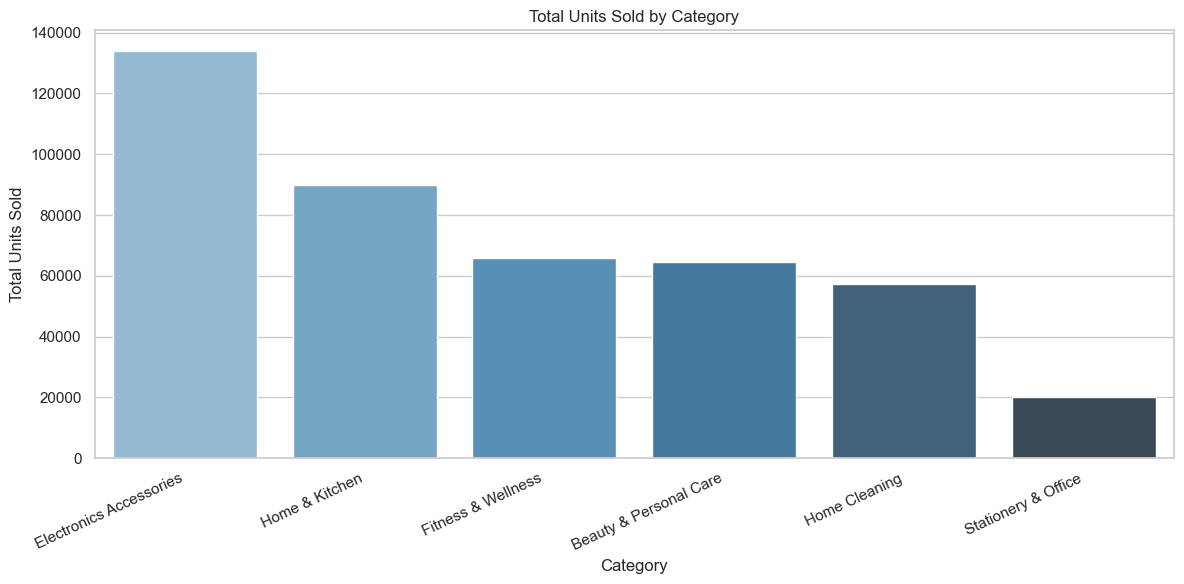

In [6]:
category_summary = (
    sales_enriched.groupby('category')
    .agg(
        total_units=('units_sold', 'sum'),
        average_units=('units_sold', 'mean'),
        demand_std=('units_sold', 'std')
    )
    .sort_values('total_units', ascending=False)
    .reset_index() 
)
category_summary['demand_share_pct'] = (
    category_summary['total_units'] / category_summary['total_units'].sum() * 100
)

display(category_summary)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_summary, x='category', y='total_units', palette='Blues_d')
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()

## 5. SKU Analysis

SKU-level analysis helps identify the products that deserve the most attention in replenishment planning.

,sku_id,total_units,average_daily_units,demand_std
33,SKU0034,13755,37.58,5.84
17,SKU0018,13702,37.44,6.31
12,SKU0013,13656,37.31,6.30
37,SKU0038,13001,35.52,7.47
4,SKU0005,12718,34.75,7.14
23,SKU0024,12515,34.19,5.95
38,SKU0039,12417,33.93,7.21
31,SKU0032,12248,33.46,6.28
6,SKU0007,12175,33.27,6.61
1,SKU0002,11643,31.81,8.13


,sku_id,total_units,average_daily_units,demand_std
24,SKU0025,8429,23.03,5.49
28,SKU0029,8497,23.22,6.04
10,SKU0011,8540,23.33,6.24
8,SKU0009,8832,24.13,7.04
11,SKU0012,9071,24.78,5.98
2,SKU0003,9400,25.68,7.40
25,SKU0026,9524,26.02,6.41
7,SKU0008,9761,26.67,6.72
35,SKU0036,9786,26.74,7.24
14,SKU0015,9826,26.85,6.73


/var/folders/qm/8t8rxfy10f7b3mdcgk6yhkgh0000gp/T/ipykernel_4614/2862775087.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skus, x='sku_id', y='total_units', palette='Greens_d')


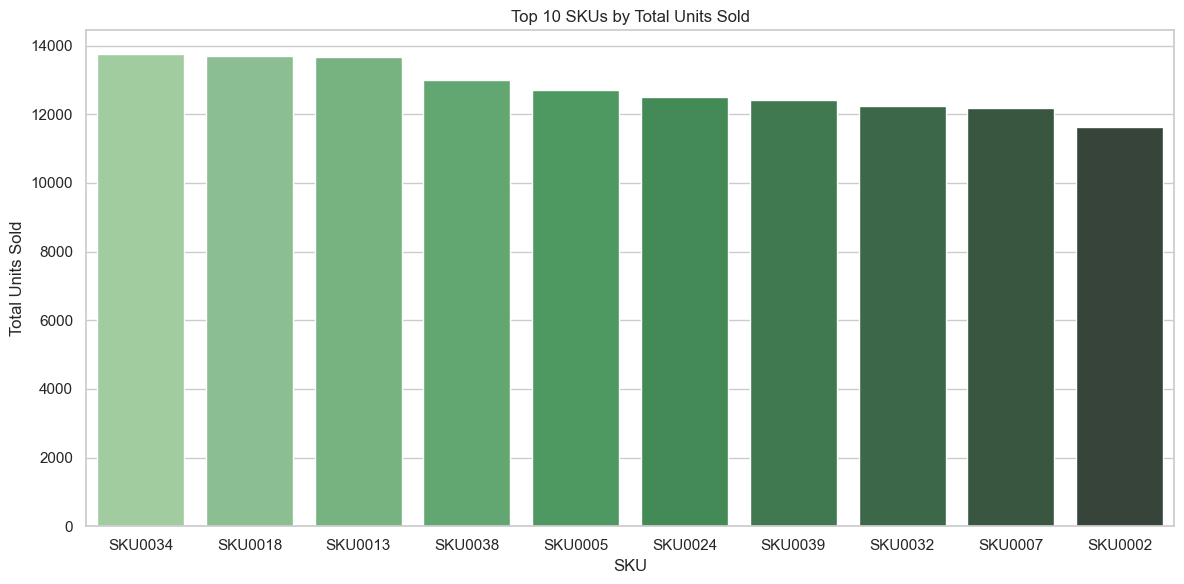

In [7]:
sku_summary = (
    sales.groupby('sku_id')
    .agg(
        total_units=('units_sold', 'sum'),
        average_daily_units=('units_sold', 'mean'),
        demand_std=('units_sold', 'std')
    )
    .reset_index()
)

top_skus = sku_summary.sort_values('total_units', ascending=False).head(10)
bottom_skus = sku_summary.sort_values('total_units', ascending=True).head(10)

display(top_skus)
display(bottom_skus)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_skus, x='sku_id', y='total_units', palette='Greens_d')
plt.title('Top 10 SKUs by Total Units Sold')
plt.xlabel('SKU')
plt.ylabel('Total Units Sold')
plt.tight_layout()

## 6. Promotion and Festival Impact Analysis

This section checks whether promotion periods and festival periods are associated with meaningful demand uplift.

,promo_flag,mean,median,count
0,0,26.60,26.00,10970
1,1,38.28,38.00,3670


,is_festival_month,mean,median,count
0,0,28.34,27.00,10960
1,1,33.05,32.00,3680


,competitor_stockout_flag,mean,median,count
0,0,29.16,28.00,12960
1,1,32.37,31.00,1680


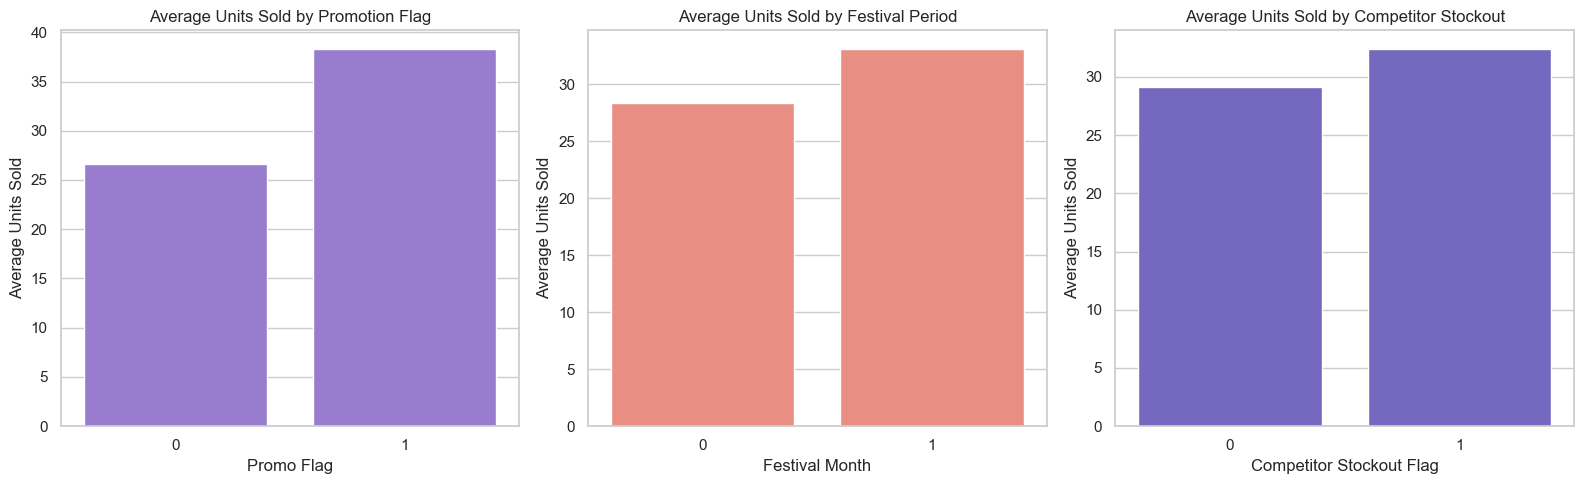

In [8]:
promo_summary = sales.groupby('promo_flag')['units_sold'].agg(['mean', 'median', 'count']).reset_index()
festival_summary = sales.groupby('is_festival_month')['units_sold'].agg(['mean', 'median', 'count']).reset_index()
competitor_summary = sales.groupby('competitor_stockout_flag')['units_sold'].agg(['mean', 'median', 'count']).reset_index()

display(promo_summary)
display(festival_summary)
display(competitor_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=promo_summary, x='promo_flag', y='mean', ax=axes[0], color='mediumpurple')
axes[0].set_title('Average Units Sold by Promotion Flag')
axes[0].set_xlabel('Promo Flag')
axes[0].set_ylabel('Average Units Sold')

sns.barplot(data=festival_summary, x='is_festival_month', y='mean', ax=axes[1], color='salmon')
axes[1].set_title('Average Units Sold by Festival Period')
axes[1].set_xlabel('Festival Month')
axes[1].set_ylabel('Average Units Sold')

sns.barplot(data=competitor_summary, x='competitor_stockout_flag', y='mean', ax=axes[2], color='slateblue')
axes[2].set_title('Average Units Sold by Competitor Stockout')
axes[2].set_xlabel('Competitor Stockout Flag')
axes[2].set_ylabel('Average Units Sold')

plt.tight_layout()

In [9]:
promo_demand = sales.loc[sales['promo_flag'] == 1, 'units_sold']
non_promo_demand = sales.loc[sales['promo_flag'] == 0, 'units_sold']
festival_demand = sales.loc[sales['is_festival_month'] == 1, 'units_sold']
non_festival_demand = sales.loc[sales['is_festival_month'] == 0, 'units_sold']

promo_t_stat, promo_p_value = ttest_ind(promo_demand, non_promo_demand, equal_var=False)
festival_t_stat, festival_p_value = ttest_ind(festival_demand, non_festival_demand, equal_var=False)

impact_tests = pd.DataFrame({
    'test': ['promotion_t_test', 'festival_t_test'],
    'statistic': [promo_t_stat, festival_t_stat],
    'p_value': [promo_p_value, festival_p_value]
})

display(impact_tests)

,test,statistic,p_value
0,promotion_t_test,98.78,0.00
1,festival_t_test,33.65,0.00


## 7. Seasonality and Calendar Patterns

Calendar effects are useful for both forecasting and reorder planning, especially when some months or seasons create higher pressure on inventory.

Season ANOVA statistic: 372.9762
Season ANOVA p-value: 0.0


,day_of_week,units_sold
0,0,29.19
1,1,29.13
2,2,29.19
3,3,29.69
4,4,28.82
5,5,29.88
6,6,30.81


,season_tag,units_sold
0,festive,33.05
2,summer,28.43
1,monsoon,28.30
3,winter,28.30


season_tag,festive,monsoon,summer,winter
category,,,,
Beauty & Personal Care,33.02,28.15,28.37,28.21
Electronics Accessories,36.86,32.12,32.06,32.08
Fitness & Wellness,29.50,24.59,24.36,24.60
Home & Kitchen,33.96,29.51,29.81,29.56
Home Cleaning,29.71,24.76,25.24,24.85
Stationery & Office,31.04,26.50,26.86,26.03


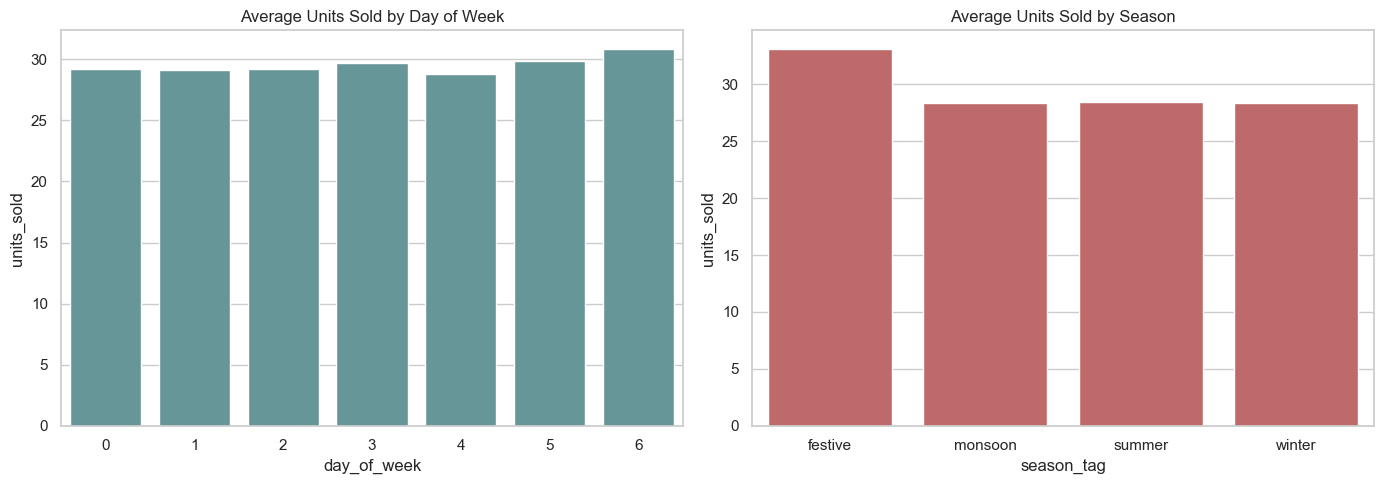

In [10]:
weekday_summary = sales.groupby('day_of_week', as_index=False)['units_sold'].mean()
season_summary = sales.groupby('season_tag', as_index=False)['units_sold'].mean()
category_seasonality = sales_enriched.pivot_table(
    index='category',
    columns='season_tag',
    values='units_sold',
    aggfunc='mean'
)

season_groups = [sales.loc[sales['season_tag'] == season_name, 'units_sold'] for season_name in ['summer', 'winter', 'monsoon', 'festive']]
season_f_stat, season_p_value = f_oneway(*season_groups)

print('Season ANOVA statistic:', round(season_f_stat, 4))
print('Season ANOVA p-value:', round(season_p_value, 8))

display(weekday_summary)
display(season_summary.sort_values('units_sold', ascending=False)) # type: ignore
display(category_seasonality)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=weekday_summary, x='day_of_week', y='units_sold', ax=axes[0], color='cadetblue') # type: ignore
axes[0].set_title('Average Units Sold by Day of Week')

sns.barplot(data=season_summary, x='season_tag', y='units_sold', ax=axes[1], color='indianred') # type: ignore
axes[1].set_title('Average Units Sold by Season')

plt.tight_layout()

## 8. Correlation Analysis

We check which numeric demand drivers move most closely with `units_sold` and visualize their relationships.

,units_sold
units_sold,1.00
discount_pct,0.63
campaign_intensity,0.51
traffic_index,0.25
rating_score,0.05
review_volume,0.03
stock_visibility_score,0.02
competitor_price_index,-0.05
weather_index,-0.08
selling_price,-0.14


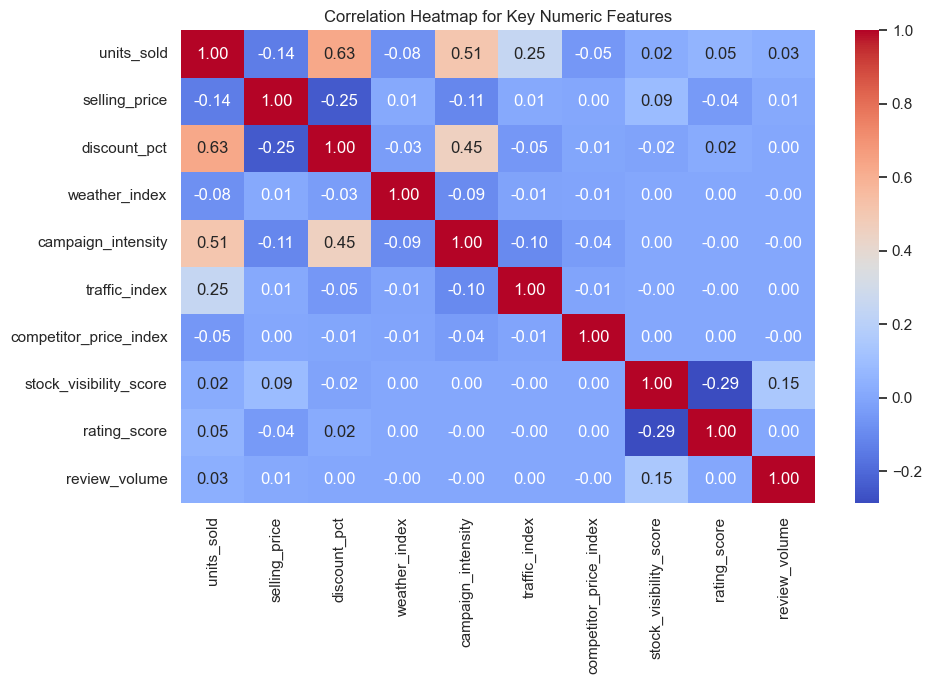

In [11]:
correlation_features = [
    'units_sold',
    'selling_price',
    'discount_pct',
    'weather_index',
    'campaign_intensity',
    'traffic_index',
    'competitor_price_index',
    'stock_visibility_score',
    'rating_score',
    'review_volume'
]

correlation_matrix = sales[correlation_features].corr()
correlation_with_target = correlation_matrix[['units_sold']].sort_values('units_sold', ascending=False)

display(correlation_with_target)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Key Numeric Features')
plt.tight_layout()

## 9. Supplier and Inventory Context

The EDA is not complete without checking the supplier and inventory signals that will later support safety stock and reorder logic.

,supplier_id,supplier_name,units_sold
2,SUP003,Skyline Imports Pvt. Ltd.,70878
4,SUP005,PrimeRoute Logistics,60654
7,SUP008,OrbitLine Sourcing,55248
5,SUP006,Vertex Retail Partners,51745
3,SUP004,UrbanEdge Wholesale,44866
6,SUP007,BlueRiver Merchants,39868
1,SUP002,NovaSupply Distributors,38687
9,SUP010,HarborPoint Global,24125
8,SUP009,Zenith Commerce LLP,23900
0,SUP001,EastBridge Trading Co.,22318


,supplier_id,supplier_name,avg_lead_time,lead_time_variability
0,SUP005,PrimeRoute Logistics,13,2
1,SUP002,NovaSupply Distributors,11,4
2,SUP003,Skyline Imports Pvt. Ltd.,10,2
3,SUP009,Zenith Commerce LLP,7,4
4,SUP007,BlueRiver Merchants,6,4
5,SUP008,OrbitLine Sourcing,5,4
6,SUP010,HarborPoint Global,5,4
7,SUP006,Vertex Retail Partners,5,2
8,SUP004,UrbanEdge Wholesale,3,4
9,SUP001,EastBridge Trading Co.,3,2


,count,mean,std,min,25%,50%,75%,max
current_stock,40.00,611.38,311.00,164.00,368.75,535.00,807.50,"1,166.00"
safety_stock,40.00,228.60,112.88,56.00,127.25,206.00,312.25,478.00
reorder_point,40.00,474.90,221.22,148.00,296.75,415.50,685.50,874.00
lead_time_days,40.00,7.42,3.46,3.00,5.00,6.00,10.00,13.00
inbound_shipment_qty,40.00,120.20,93.02,2.00,47.50,102.50,175.25,337.00


/var/folders/qm/8t8rxfy10f7b3mdcgk6yhkgh0000gp/T/ipykernel_4614/695447130.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=supplier_demand, x='supplier_id', y='units_sold', palette='magma')


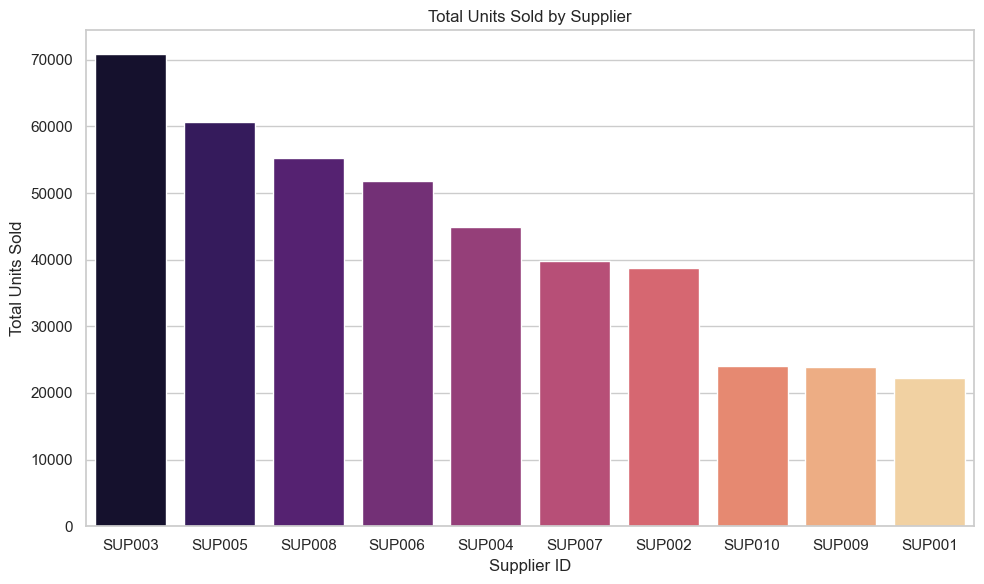

In [ ]:
supplier_demand = (
    sales_enriched.groupby(['supplier_id', 'supplier_name'], as_index=False)['units_sold']
    .sum()
    .sort_values('units_sold', ascending=False)
) # type: ignore

supplier_risk = suppliers.sort_values(['avg_lead_time', 'lead_time_variability'], ascending=False).reset_index(drop=True)
inventory_summary = inventory[['current_stock', 'safety_stock', 'reorder_point', 'lead_time_days', 'inbound_shipment_qty']].describe().T

display(supplier_demand)
display(supplier_risk)
display(inventory_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=supplier_demand, x='supplier_id', y='units_sold', palette='magma')
plt.title('Total Units Sold by Supplier')
plt.xlabel('Supplier ID')
plt.ylabel('Total Units Sold')
plt.tight_layout()

## 10. Business Insights

This final section summarizes the most decision-relevant findings from the analysis above.

In [13]:
top_category = category_summary.iloc[0]
top_sku = top_skus.iloc[0]
promo_lift = promo_summary.loc[promo_summary['promo_flag'] == 1, 'mean'].iloc[0] - promo_summary.loc[promo_summary['promo_flag'] == 0, 'mean'].iloc[0]
festival_lift = festival_summary.loc[festival_summary['is_festival_month'] == 1, 'mean'].iloc[0] - festival_summary.loc[festival_summary['is_festival_month'] == 0, 'mean'].iloc[0]
strongest_driver = correlation_with_target.drop(index='units_sold').index[0]

insights = [
    f"1. The highest-demand category is **{top_category['category']}**, contributing {top_category['total_units']:,.0f} units and {top_category['demand_share_pct']:.2f}% of total category demand.",
    f"2. The top-selling SKU is **{top_sku['sku_id']}**, with {top_sku['total_units']:,.0f} units sold over the year.",
    f"3. Promotions lift average demand by **{promo_lift:.2f} units** per record compared with non-promotion periods.",
    f"4. Festival months lift average demand by **{festival_lift:.2f} units** per record compared with non-festival periods.",
    f"5. The strongest numeric relationship with demand in this EDA is **{strongest_driver}**, which should be carried forward into forecasting and inventory planning."
]

for insight in insights:
    display(Markdown(insight))

1. The highest-demand category is **Electronics Accessories**, contributing 134,038 units and 31.01% of total category demand.

2. The top-selling SKU is **SKU0034**, with 13,755 units sold over the year.

3. Promotions lift average demand by **11.67 units** per record compared with non-promotion periods.

4. Festival months lift average demand by **4.71 units** per record compared with non-festival periods.

5. The strongest numeric relationship with demand in this EDA is **discount_pct**, which should be carried forward into forecasting and inventory planning.